## 로지스틱 회귀
- 선형 회귀와 비슷하지만 활성화 함수(시그드모어,소프트맥스)를 추가하여 __분류__ 가 가능한 모델로

### 회귀?
- 로지스틱은 최종적으로 클래스(정답)을 분류 하는 알고리즘이다
- 다만 그 분류를 위해 확률을 모델링 하는 회귀 방식을 사용하기 때문
- 회귀 모델에서의 정규화와 달리 '0~1 사이의 확률값' 으로 가공하여 분류를 수행한다

### 활성화 함수
- 선형 회귀로 먼저 예측 점수인 z를 계산한 뒤 활성화 함수에 넣어서 0~1사이 값으로 표현한다
- 이진 분류 모델 흐름
    1. 입력 : 원본 데이터 (꽃잎 길이, 꽃잎 너비)
    2. 연산 : 가중치(w)와 편향(b)을 결합하여 계산 (z = wx + b)(선형회귀)
    3. 변환 : 활성화 함수(시그드모어, 소프트맥스)를 통과시켜 0~1 사이 숫자(확률)로 가공
    4. 결정 : 도출된 확률이 0.5 이상이면 클래스1, 아니면 클래스0 (이진 분류 모델이기에 답이 2개 인 경우)

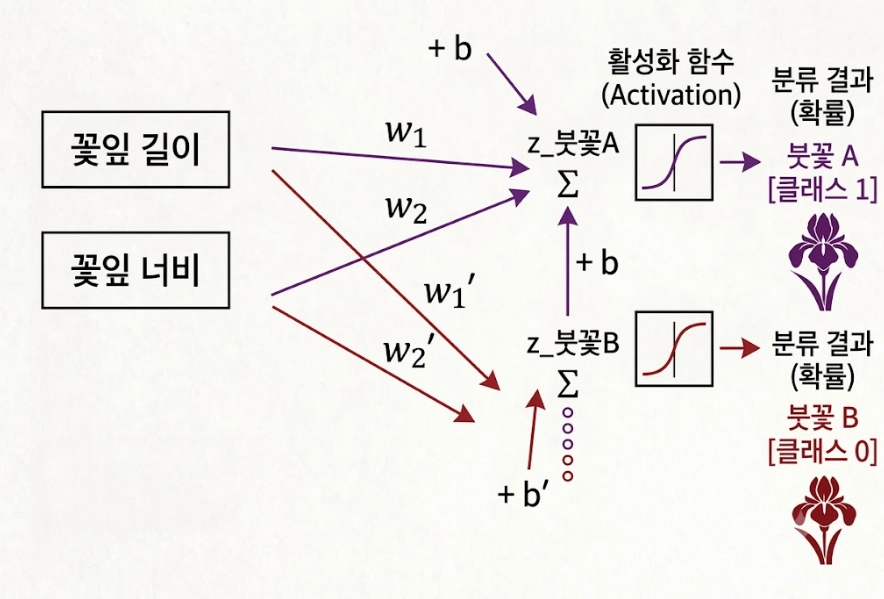


### 손실 함수
- 예측과 정답이 얼마나 다른지를 보여주는 손실 함수

- MSE : 실제값과 예측값의 거리 - 차이를 제곱하여 벌점 부여
    - 확률 분류 문제에 적용하면 오차가 클 때도 별점이 완만하게 증가하여 최적의 학습 가중치를 찾기 어렵다

- 크로스 엔트로피 (Cross Entropy) : 분류용
    - 분류는 확률을 맞추는 모델
    - 모델의 확신 수준에 따라 벌금 부여
        - 정답일 확률을 99%로 예측 한다면 벌점은 0에 수렴하나 반대의 경우 (1%로 예측)하는 경우 무한대에 가까운 벌점 부여
            - 틀렸는데(1%) 인데도 정답이라고 예측하기에 더 과도하게 부여함

    - 형태
        - 2진 크로스 엔트로피 (Binary Cross Entropy)
            - 선택지가 2개인 경우에 사용
            - 활성화 함수 : 시그모이드

        - 범주형 크로스 엔트로피
            - 선택지가 3개 이상인 경우에 사용
            - 활성화 함수 : 소프트맥스
            - 클래스가 3개 있는 경우 클래스1 [1,0,0], 클래스2 [0,1,0], 클래스3 [0,0,1] 등의 원-핫 인코딩 형태
            - 클래스가 많아질수록 메모리 부담이 늘어나고 연산량이 늘어나 모델이 성능이 떨어지게 된다
            - 그래서 잘 안씀

        - 희소 범주형 크로스 엔트로피(Sparse Categorical Cross Entropy)
            - 선택지가 3개 이상인 경우에 사용
            - 활성화 함수: 소프트맥스
            - 정답이 정수형 레이블 형태

### K-Fold 교차 검증
- 테스트 데이터가 우연히 모델에 유리하게 들어가지 않도록 데이터를 섞어 주는 기능
- 코드 예시
```
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
```
    
### 시그모이드와 소프트맥스
- 시그모이드 : 선택지가 2개인 상황에서 예, 아니오를 선택하기 위한 함수

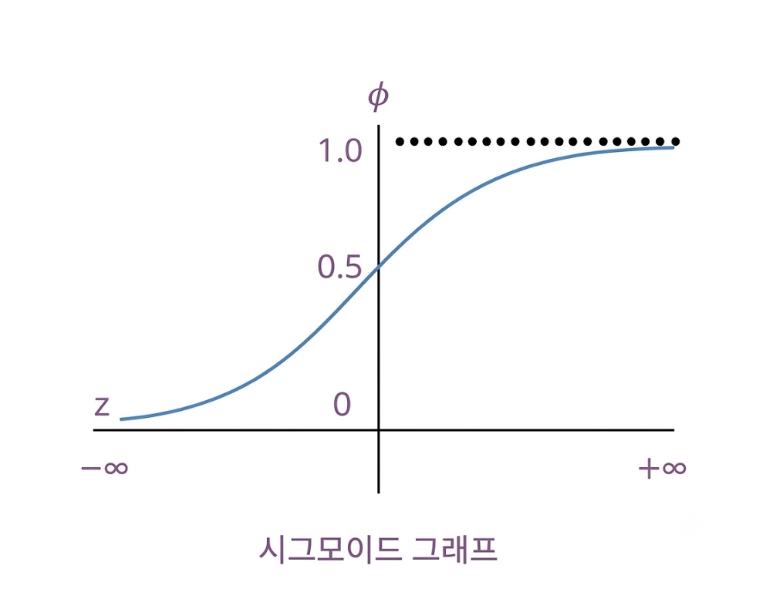

- 소프트맥스 : 다중 분류와 확률 분포 변환

$$
\text{소프트맥스 결과} = \frac{\text{내가 관심 있는 클래스의 지수화된 점수}}{\text{모든 클래스의 지수화된 점수 총합}}
$$


## 파이토치
- 현재 내가 이해하고 있는것
- 로지스틱 회귀 모델에서 은닉층을 추가하여 모델이 더 다양한 연산을 거치게 되어 더 고차원적인 정답을 이끌어 낼 수 있음
- 은닉층에도 활성화 함수가 추가 된다
    - 그로인해 선형적 계산은 동일하게 이루어지지만 비선형성을 가지게 된다
- 은닉층이 추가될수록 모델의 연산은 더 많아진다
    - 입력층(1234) -> 은닉층(0.23) -> 은닉층2(0.11)
        - Gradients(기울기)가 은닉층을 통과하면 점점 작아짐
        - 가중치 업데이트가 미미 해진다
        - 학습이 이루어지지 않음

